 # <font color="#6600ff"> Gender Classification Using CNN Projesi: </font>

&nbsp;&nbsp;&nbsp; Parmak izinden cinsiyet sınıflandırması yapılabildiğini biliyor muydunuz? Her insanın parmak izleri benzersizdir. Bu projede insanların parmak izlerini CNN yardımıyla işleyip bu kişilerin cinsiyetini belirleyebilen bir model oluşturacağız. Datamız parmak izlerini içeren veri setinden yani klasörlerden oluşuyor. Bu preoje bu bir 'Classification' projesidir. Çalışmamızı **Derin Öğrenme** ile gerçekleştireceğiz. Modelimiz üzerinde dolaylı amacımız modelin tahmin oranını %80 üzerinde tutmak olacaktır.  

In [23]:
# Merhaba,
# Bu ödevde verilecek cevaplarıma kullanmak adına karar kıldığım Font '#6600ff' dur.

#### **Veri Setimiz:** <br>
**Altered:** Bu klasör içerisindeki 'Altered-Easy', 'Altered-Medium' ve 'Altered-Hard' dosyalarındaki resimler parmak izlerini içerir.  <br>
**Real:** Test resimlerini içeren klasör <br>

***Hedef Sütunumuz:*** 'label_encoded' (0 ifadesi 'Altered-Easy' iken, 1 ifadesi 'Altered-Medium' ve 2 ifadesi 'Altered-Hard' resimleri temsil eder).  

<img src='https://bilimgenc.tubitak.gov.tr/sites/default/files/styles/bp-770px-custom_user_desktop_1x/public/parmak_izi.jpg?itok=NrP_Jkcm'>

In [38]:
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

from keras.models import Sequential
from keras.layers import Conv2D,Dense,Flatten,Input,MaxPooling2D,Dropout,BatchNormalization,Reshape
from keras.utils import to_categorical

import os
import matplotlib.pyplot as plt
import random
from pathlib import Path
from PIL import Image

&nbsp;&nbsp;&nbsp;Gerekli kütüphaneleri çağırdıktan sonra veri setimizi inceliyoruz ve düzenliyoruz.

## <font color="#6600ff"> Feature Engineering: </font>

&nbsp;&nbsp;&nbsp;Öncelikle veri setimizden örnek parmak izleri göstererek başlayalım. Daha sonra resimler üzerinde düzenlemeler yapıyor olacağız.

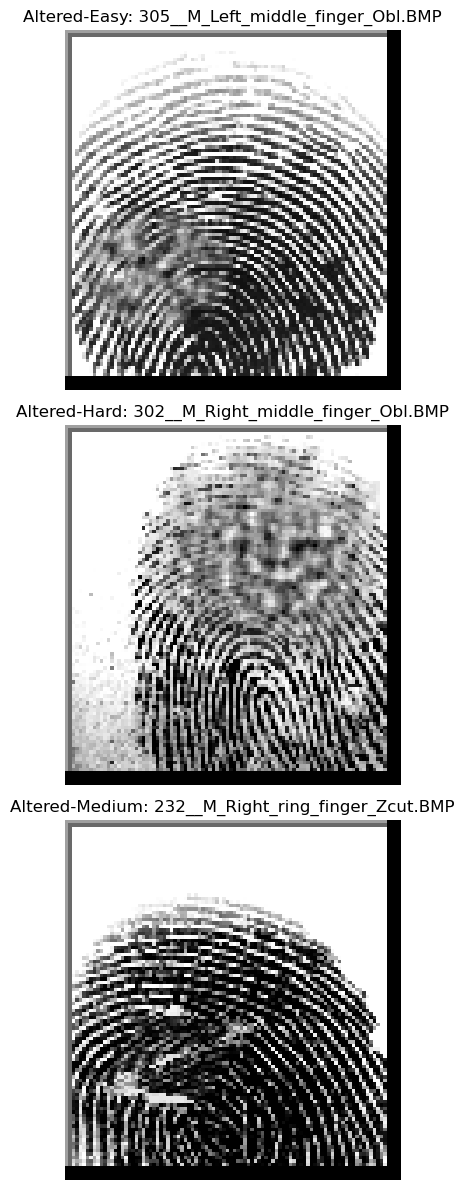

In [39]:
train_dir = Path('Altered/')
classes = [d for d in train_dir.iterdir() if d.is_dir()]

# Her sınıftan 1 örnek, toplam sınıf sayısı kadar göster
images_per_class = 1
fig, axes = plt.subplots(len(classes), images_per_class, figsize=(4*images_per_class, 4*len(classes)))
if len(classes) == 1:
    axes = [axes]  # tek sınıf için erişimi kolaylaştır

for i, cls in enumerate(classes):
    img_files = list(cls.glob('*'))
    if not img_files:
        continue
    chosen = random.choice(img_files)
    img = Image.open(chosen).convert('RGB')
    ax = axes[i] if images_per_class == 1 else axes[i, 0]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{cls.name}: {chosen.name}')

plt.tight_layout()
plt.show()

&nbsp;&nbsp;&nbsp;Datamız resimlerden oluştuğu için klasörleri projemize ekleyip üç etiket altında ayırıyoruz klasör başlıkları ile.

In [7]:
labels=['Altered-Easy','Altered-Hard', 'Altered-Medium']
img_path='Altered/' 

In [8]:
img_list=[]
label_list=[]
for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(img_path+label+"/"+img_file)
        label_list.append(label)

&nbsp;&nbsp;&nbsp;Üç farklı klasörü 'label' altında topladıktan sonra, resimlerin yollarını belirten bilgiyi de 'img' altına toplayarak her iki bilgiyi DataFrame haline getirerek onları sütunlaştırıyoruz işleyebilmek adına. 

In [9]:
df = pd.DataFrame({'img':img_list, 'label':label_list})

In [10]:
df

,img,label
0,Altered/Altered-Easy/100__M_Left_index_finger_...,Altered-Easy
1,Altered/Altered-Easy/100__M_Left_index_finger_...,Altered-Easy
2,Altered/Altered-Easy/100__M_Left_index_finger_...,Altered-Easy
3,Altered/Altered-Easy/100__M_Left_little_finger...,Altered-Easy
4,Altered/Altered-Easy/100__M_Left_little_finger...,Altered-Easy
...,...,...
49265,Altered/Altered-Medium/9__M_Right_ring_finger_...,Altered-Medium
49266,Altered/Altered-Medium/9__M_Right_ring_finger_...,Altered-Medium
49267,Altered/Altered-Medium/9__M_Right_thumb_finger...,Altered-Medium
49268,Altered/Altered-Medium/9__M_Right_thumb_finger...,Altered-Medium


&nbsp;&nbsp;&nbsp;Daha sonra 'label' sütunu altında yer alan üç farklı klasörü temsil eden değerleri bool değerler haline getirip onlardan 'label_encoded' adlı sütunu yaratıyoruz. 

In [11]:
d=({'Altered-Easy':0, 'Altered-Medium':1,'Altered-Hard':2})
df['label_encoded']=df['label'].map(d)

In [12]:
df

,img,label,label_encoded
0,Altered/Altered-Easy/100__M_Left_index_finger_...,Altered-Easy,0
1,Altered/Altered-Easy/100__M_Left_index_finger_...,Altered-Easy,0
2,Altered/Altered-Easy/100__M_Left_index_finger_...,Altered-Easy,0
3,Altered/Altered-Easy/100__M_Left_little_finger...,Altered-Easy,0
4,Altered/Altered-Easy/100__M_Left_little_finger...,Altered-Easy,0
...,...,...,...
49265,Altered/Altered-Medium/9__M_Right_ring_finger_...,Altered-Medium,1
49266,Altered/Altered-Medium/9__M_Right_ring_finger_...,Altered-Medium,1
49267,Altered/Altered-Medium/9__M_Right_thumb_finger...,Altered-Medium,1
49268,Altered/Altered-Medium/9__M_Right_thumb_finger...,Altered-Medium,1


&nbsp;&nbsp;&nbsp;Şimdi elimizde olan resimleri işleyebilmek adına boyutlandırıp, normalize ediyoruz.

In [20]:
max_images_per_class = 3000  # Her sınıftan alınacak maksimum resim sayısı
x = []  # Resimler için boş liste
y = []  # Etiketler için boş liste

# Her sınıf için bellek kullanımını azaltacak örnekleme işlemi
for label in df['label'].unique():  # Her sınıfı döngü ile gez
    class_images = df[df['label'] == label].sample(n=min(max_images_per_class, len(df[df['label'] == label])), random_state=42)  # Sınıfa ait rastgele örnekler al
    for img_path in class_images['img']:
        img = cv2.imread(str(img_path))  # Resmi oku
        if img is not None:  # Resmin başarıyla okunduğundan emin ol
            img = cv2.resize(img, (170, 170))  # Yeniden boyutlandır
            img = img.astype(np.float32) / 255.0  # Normalize et
            x.append(img)  # Resmi listeye ekle
            y.append(df[df['img'] == img_path]['label_encoded'].values[0])  # İlgili etiket değerini al ve ekle
        else:
            print(f"Resim okunamadı: {img_path}")  # Hata mesajı ver

# Numpy dizilerine dönüştür
x = np.array(x)
y = np.array(y)

# Sonuçları kontrol et
print(f"Yüklenen resim sayısı: {len(x)}")
print(f"Y etiketi boyutu: {len(y)}")

Yüklenen resim sayısı: 9000
Y etiketi boyutu: 9000


&nbsp;&nbsp;&nbsp; Şimdi düzenlemeler bitmiş oldu ve modelleme kısmına geçiyoruz.

## <font color="#6600ff"> Model and Testing: </font>

&nbsp;&nbsp;&nbsp;Modelimizin hedefi ve işlenecek datası belli olduğuna göre onu eğitim ve test kısımlarına ayırıp test edip modelleyelim.

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [26]:
y_train = to_categorical(y_train, num_classes=3)  # 3 sınıf
y_test = to_categorical(y_test, num_classes=3)

&nbsp;&nbsp;&nbsp;Modelimizi Deep Learning ile eğitiyoruz.

In [27]:
# Model
model = Sequential()
model.add(Input(shape=(170, 170, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  # maxpooling aşırı ezberlemeyi engelliyor
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))  # Activation function added
model.add(Dense(3, activation='softmax'))  # softmax multi-class classification'da kullaniliyor!!

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Categorical loss for multi-class

In [28]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test), epochs=20,verbose=1)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 59s 255ms/step - accuracy: 0.3332 - loss: 1.3162 - val_accuracy: 0.3411 - val_loss: 1.0985
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 55s 245ms/step - accuracy: 0.4049 - loss: 1.0614 - val_accuracy: 0.5261 - val_loss: 0.9490
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 55s 246ms/step - accuracy: 0.5425 - loss: 0.9298 - val_accuracy: 0.5383 - val_loss: 0.9234
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 55s 246ms/step - accuracy: 0.5678 - loss: 0.8766 - val_accuracy: 0.5917 - val_loss: 0.8672
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 56s 251ms/step - accuracy: 0.6153 - loss: 0.8128 - val_accuracy: 0.5833 - val_loss: 0.8676
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 260ms/step - accuracy: 0.6662 - loss: 0.7295 - val_accuracy: 0.5650 - val_loss: 0.8880
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 56s 251ms/step - accuracy: 0.7146 - loss: 0.6338 - val_accuracy: 0.5672 - val_loss: 0.9386
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 56s 247ms/step - accuracy: 0.7732 - loss: 0

&nbsp;&nbsp;&nbsp; Ve modelimizi kaydedelim.

In [29]:
model.save('gender_classification.h5')

&nbsp;&nbsp;&nbsp; Şimdi de modelimizin özetini inceleyelim.

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 168, 168, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 84, 84, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 82, 82, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 41, 41, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 107584)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      13,770,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,371,979 (157.82 MB)

 Trainable params: 13,790,659 (52.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,581,320 (105.21 MB)

In [31]:
history.history['accuracy']

[0.33319443464279175,
 0.40486112236976624,
 0.5425000190734863,
 0.5677777528762817,
 0.6152777671813965,
 0.6662499904632568,
 0.7145833373069763,
 0.773194432258606,
 0.8106944561004639,
 0.8602777719497681,
 0.8943055272102356,
 0.914722204208374,
 0.9387500286102295,
 0.9513888955116272,
 0.9623610973358154,
 0.9624999761581421,
 0.9745833277702332,
 0.9738888740539551,
 0.9795833230018616,
 0.9831944704055786]

&nbsp;&nbsp;&nbsp;Ve yukarıda olduğu gibi modelimizin doğruluk oranının geçmişine bakarsak, tahmin oranımız %98'leri buluyor gibi model datamızı öğrendikçe.

&nbsp;&nbsp;&nbsp;Şimdi modelimizin datayı iyi öğrendiğini ve iyi tahmin yapabildiğini zaten son gelen accuracy oranlarından anlıyoruz ama bunu yine görselleştirelim. 

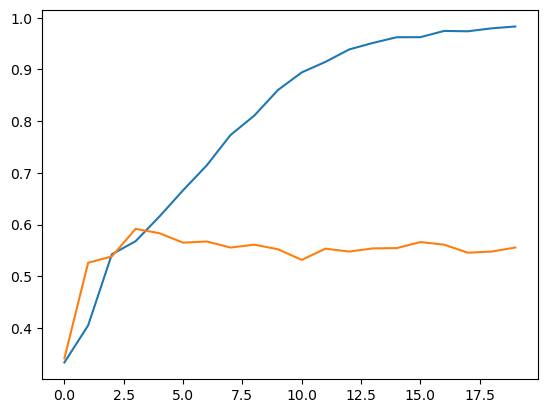

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy']);

**Conclusion:** &nbsp;&nbsp;Sonuç olarak kendi modelimizi kaydettiğimiz 'gender_classification.h5' modeline bakılırsa 'accuracy: 0.9831' leri görüyor. Bu demektir ki modelimiz verilen parmak izlerinden bir kişinin kadın mı erkek mi olduğunu sınıflandırırken tahmin yaptığında doğruluk oranı çok yüksek ve eğitim datası modelimiz tarafından gayet iyi anlaşılmış ve eğitilmiştir. <br><br>
&nbsp;&nbsp;&nbsp;Bu çalışmada görüldüğü üzere modelleme aracılığıyla bir insanın cinsiyeti kolaylıkla sınıflandırıp, bu belirleme işlemi yapay zeka rahatça bırakılabilir.

Ve kapanış..